# Notebook 05 — Model Preparation & Baseline Model

## Objective

This notebook prepares the engineered dataset for machine learning by:

- Loading the final processed dataset
- Splitting features and target
- Creating training and testing datasets
- Applying feature scaling
- Training a baseline Logistic Regression model
- Evaluating model performance

In [61]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [62]:
df = pd.read_csv("../data/processed/engineered_data.csv")

print("Dataset Loaded Successfully\n")

print("Shape :", df.shape)

df.head()

Dataset Loaded Successfully

Shape : (101766, 79)


,encounter_id,patient_nbr,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady
0,2278392,8222157,-3.824600,6,25,1,-1.137649,-0.106517,-0.785398,-1.848268,...,1,0,0,1,0,0,0,0,0,0
1,149190,55629189,-3.197277,1,1,7,-0.467653,0.808384,-0.785398,0.243390,...,0,0,1,1,0,0,0,0,0,0
2,64410,86047875,-2.569954,1,1,7,-0.802651,-1.631351,2.145781,-0.371804,...,1,0,0,1,0,0,0,0,0,0
3,500364,82442376,-1.942632,1,1,7,-0.802651,0.045967,-0.199162,-0.002688,...,0,0,1,1,0,0,0,0,0,0
4,16680,42519267,-1.315309,1,1,7,-1.137649,0.401761,-0.785398,-0.986997,...,0,1,0,1,0,0,0,0,0,0


In [63]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 79 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   encounter_id                     101766 non-null  int64  
 1   patient_nbr                      101766 non-null  int64  
 2   age                              101766 non-null  float64
 3   admission_type_id                101766 non-null  int64  
 4   discharge_disposition_id         101766 non-null  int64  
 5   admission_source_id              101766 non-null  int64  
 6   time_in_hospital                 101766 non-null  float64
 7   num_lab_procedures               101766 non-null  float64
 8   num_procedures                   101766 non-null  float64
 9   num_medications                  101766 non-null  float64
 10  number_outpatient                101766 non-null  float64
 11  number_emergency                 101766 non-null  float64
 12  number_inpati

In [64]:
# Features
X = df.drop("readmitted", axis=1)

# Target
y = df["readmitted"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

print("\nTarget Distribution")

print(y.value_counts())

Feature Shape : (101766, 78)
Target Shape : (101766,)

Target Distribution
readmitted
0    54864
1    46902
Name: count, dtype: int64


In [65]:
print("Object Columns in X")

print(X.select_dtypes(include=["object", "string"]).columns.tolist())

Object Columns in X
[]


In [66]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (81412, 78)
Testing Shape : (20354, 78)


In [67]:
print("Object Columns in X_train")

print(X_train.select_dtypes(include=["object", "string"]).columns.tolist())

Object Columns in X_train
[]


In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


In [69]:
model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Model Trained Successfully.")

Model Trained Successfully.


In [70]:
y_pred = model.predict(X_test_scaled)

In [71]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.6325


In [72]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.63      0.77      0.69     10973
           1       0.64      0.47      0.54      9381

    accuracy                           0.63     20354
   macro avg       0.63      0.62      0.62     20354
weighted avg       0.63      0.63      0.62     20354



In [73]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[8483 2490]
 [4991 4390]]


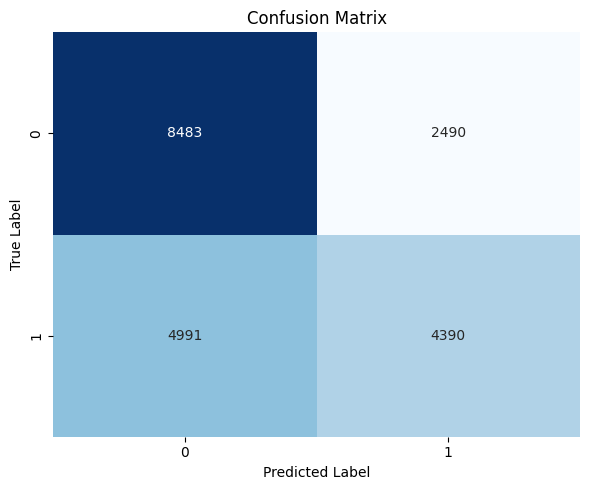

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.savefig("../images/logistic_confusion_matrix.png", dpi=300)
plt.show()

## Model Summary

The Logistic Regression model was trained successfully using the engineered dataset.

Evaluation was performed using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

This model serves as the baseline for comparing more advanced machine learning algorithms in the following notebooks.